In [10]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, Sequential

## Preprocessing

In [2]:
#Load all datasets(imagers)

# Paths
image_folder = 'images/train/'  #includes all training set images
label_folder = 'images/train_labels/' #includes text files that says 'Vehicle detected' or 'Vehicle not detected'
# Need to uncompress the archived directory to get the images

X = [] # images set
Y = [] # values 

# Read all images and labels
for image_file in os.listdir(image_folder):
    if image_file.endswith('.jpg'):
        img_path = os.path.join(image_folder, image_file)
        label_path = os.path.join(label_folder, os.path.splitext(image_file)[0] + '.txt')

        # Load and resize image
        img = Image.open(img_path).convert('RGB')
        img = img.resize((128, 128))  # Resize to 128x128
        img = np.array(img) / 255.0    # Normalize to 0-1
        X.append(img)

        # Load label
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                text = f.read()
                if 'Vehicle detected' in text:
                    Y.append(1)
                else:
                    Y.append(0)
        else:
            Y.append(0)

# Convert to numpy arrays
X = np.array(X)
Y = np.array(Y)

print(f" Loaded {X.shape[0]} images.")
print(f"X shape: {X.shape}")  # Should be (num_samples, 128, 128, 3)
print(f"Y shape: {Y.shape}")  # Should be (num_samples,)


 Loaded 1018 images.
X shape: (1018, 128, 128, 3)
Y shape: (1018,)


## Split train validation data sets with 80%/20% ratio

In [4]:

# Split total data into 80% train, 20% validation 
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y  # Important: keep same class distribution
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Training samples: 814
Validation samples: 204


## Example of training dataset with car 

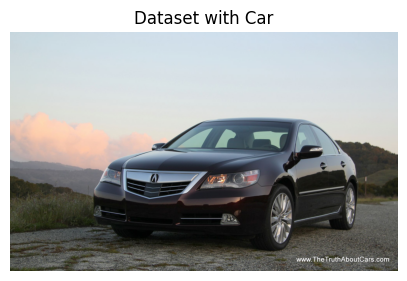

In [45]:
# Provide full path to your image
img_path = 'images/train/000090.jpg'   

# Load and show
img = Image.open(img_path)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title('Dataset with Car')
plt.axis('off')
plt.show()

## Training Dataset examples without car

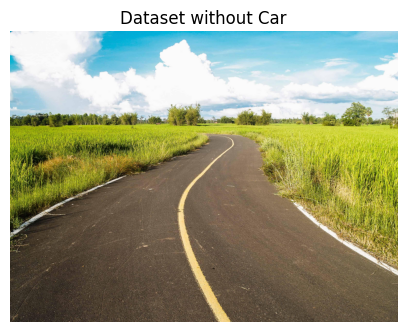

In [46]:
# Provide full path to your image
img_path = 'images/train/dhs_custom_6.jpg'   

# Load and show
img = Image.open(img_path)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title('Dataset without Car')
plt.axis('off')
plt.show()

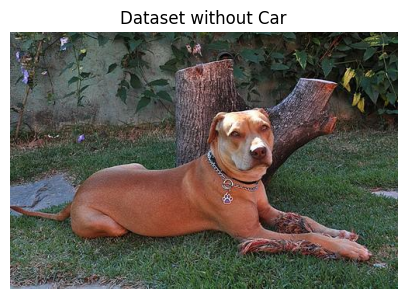

In [47]:
# Provide full path to your image
img_path = 'images/train/dhs_custom_462.jpg'   

# Load and show
img = Image.open(img_path)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title('Dataset without Car')
plt.axis('off')
plt.show()

## Augment data for better training model 

In [7]:
# Set up Data Augmentation
datagen = ImageDataGenerator(
    horizontal_flip=True,        # Randomly flip images horizontally
    rotation_range=20,           # Randomly rotate images up to 20 degrees
    zoom_range=0.2,              # Random zoom inside images
    width_shift_range=0.1,       # Random horizontal shift
    height_shift_range=0.1       # Random vertical shift
)

datagen.fit(X_train)             # Apply data augmentation fitting to training data

## Computer class weights between 2 classes

In [8]:
# Compute Class Weights (handle imbalance between classes)
class_weights = compute_class_weight(
    class_weight='balanced',         # Automatically balance the classes
    classes=np.unique(Y_train),       # Classes present in training data
    y=Y_train                         # Training labels
)

# Creating a dictionary for class label -> weight
classes_in_data = np.unique(Y_train)
class_weight_dict = {classes_in_data[i]: class_weights[i] for i in range(len(classes_in_data))}

print(" Class Weights:", class_weight_dict)

 Class Weights: {np.int64(0): np.float64(1.0571428571428572), np.int64(1): np.float64(0.9487179487179487)}


## Build CNN model

In [11]:
# Building Model (CNN for binary classification)
dharav_model = Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),  # Conv layer 1
    layers.BatchNormalization(),   
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation="relu"),                            # Conv layer 2
    layers.BatchNormalization(),   
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation="relu"),                           # Conv layer 3
    layers.Flatten(),                                                       # Flatten feature maps

    layers.Dense(128, activation="relu"),                                   # Dense hidden layer
    layers.BatchNormalization(),   
    layers.Dropout(0.5),                                                    # Dropout for regularization
    layers.Dense(1, activation="sigmoid")                                   # Output layer: Sigmoid for binary classification
])

C:\Users\dharav\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compiling the model

In [12]:
# Compiling the Model
dharav_model.compile(
    optimizer=RMSprop(learning_rate=1e-4),       # Lower learning rate for stable training
    loss='binary_crossentropy',                  # Binary classification loss
    metrics=['accuracy']                         # Track accuracy
)

## Fit the model with datagen with 30 epochs

In [13]:
# Train the Model
history = dharav_model.fit(
    datagen.flow(X_train, Y_train, batch_size=32),  # Train using augmented data
    validation_data=(X_val, Y_val),                 # Validation dataset
    epochs=30,                                      # Train for 30 epochs
    class_weight=class_weight_dict                  # Apply class weighting
)

C:\Users\dharav\anaconda3\envs\tf_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 486ms/step - accuracy: 0.7975 - loss: 0.4962 - val_accuracy: 0.4706 - val_loss: 0.8408
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 472ms/step - accuracy: 0.9089 - loss: 0.2149 - val_accuracy: 0.4706 - val_loss: 1.8431
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 469ms/step - accuracy: 0.9103 - loss: 0.2173 - val_accuracy: 0.4706 - val_loss: 2.1358
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 515ms/step - accuracy: 0.9214 - loss: 0.1753 - val_accuracy: 0.4706 - val_loss: 3.1479
Epoch 5/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 578ms/step - accuracy: 0.9470 - loss: 0.1284 - val_accuracy: 0.4706 - val_loss: 3.9071
Epoch 6/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 523ms/step - accuracy: 0.9371 - loss: 0.1441 - val_accuracy: 0.4706 - val_loss: 2.9815
Epoch 7/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 539ms/step - accuracy: 0.9518 - loss: 0.1193 - val_accuracy: 0.4706 - val_loss: 3.5607
Epoch 8/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 510ms/step - accuracy: 0.9761 - loss: 0.0979 - val_accu

## Accuracy and Loss plot for training dataset

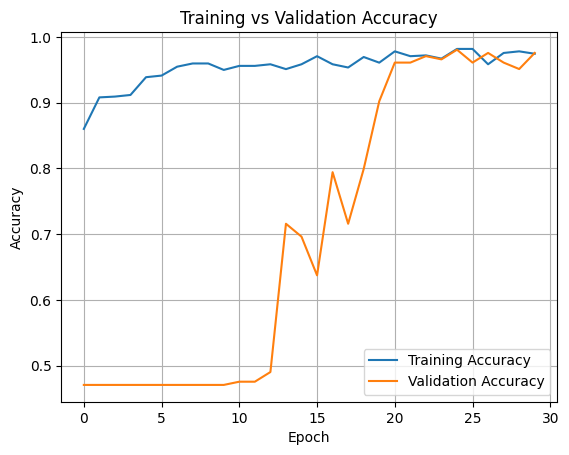

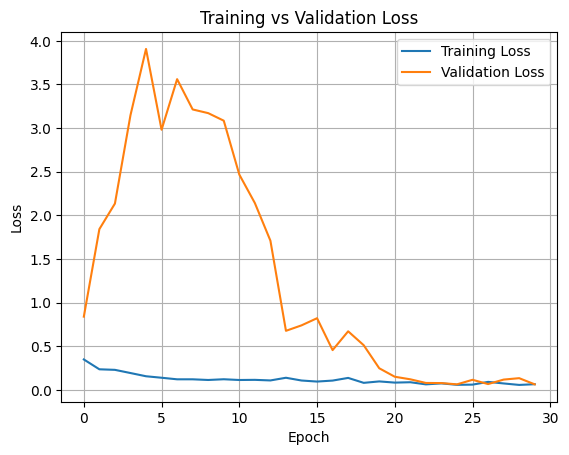

In [15]:
# Plot Training Curves
# Accuracy Plot
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss Plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

## Examples of test datasets

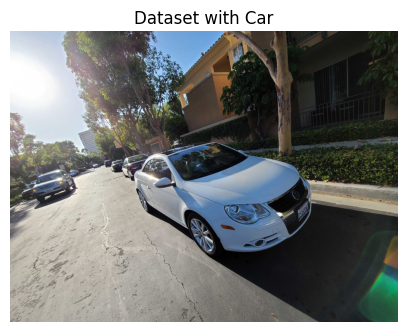

In [49]:
# Provide full path to your image
img_path = 'images/test/20200618_180553.jpg'  

# Load and show
img = Image.open(img_path)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title('Dataset with Car')
plt.axis('off')
plt.show()

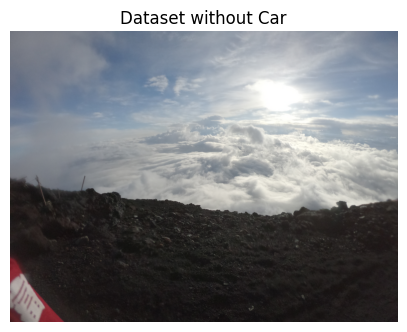

In [52]:
# Provide full path to your image
img_path = 'images/test/GOPR1700.jpg'  

# Load and show
img = Image.open(img_path)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title('Dataset without Car')
plt.axis('off')
plt.show()

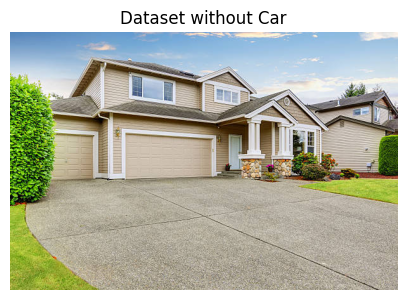

In [53]:
# Provide full path to your image
img_path = 'images/test/driveway1.jpg'   # 👉 replace with your image path

# Load and show
img = Image.open(img_path)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title('Dataset without Car')
plt.axis('off')
plt.show()

## Check the test dataset with the trained model 

Loaded 37 test images.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8863 - loss: 0.2637

Test Accuracy: 0.8919
Test Loss: 0.2531
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step 


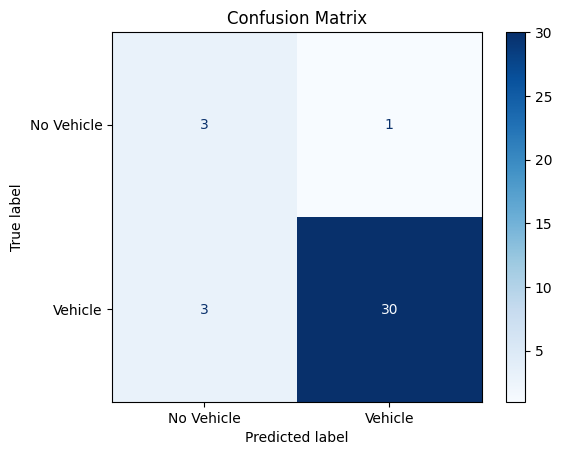

In [36]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Paths
test_image_folder = 'images/test/'         
test_label_folder = 'images/test_labels/'    

# Load Test Data
X_test = []
Y_test = []

# Read all images and corresponding labels
for image_file in os.listdir(test_image_folder):
    if image_file.endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join(test_image_folder, image_file)
        label_path = os.path.join(test_label_folder, os.path.splitext(image_file)[0] + '.txt')

        # Load and preprocess image
        img = Image.open(img_path).convert('RGB')
        img = img.resize((128, 128))  # Must match training size
        img = np.array(img) / 255.0   # Normalize
        X_test.append(img)

        # Load label
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                text = f.read()
                if 'Vehicle Detected' in text:
                    Y_test.append(1)
                else:
                    Y_test.append(0)
        else:
            Y_test.append(0)

# Convert to numpy arrays
X_test = np.array(X_test)
Y_test = np.array(Y_test)

print(f"Loaded {X_test.shape[0]} test images.")

# Evaluate the Model
test_loss, test_accuracy = dharav_model.evaluate(X_test, Y_test)

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Predict Probabilities
y_pred_probs = dharav_model.predict(X_test)

# Convert probabilities to binary labels
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Plot Confusion Matrix (optional)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(Y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Vehicle", "Vehicle"])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


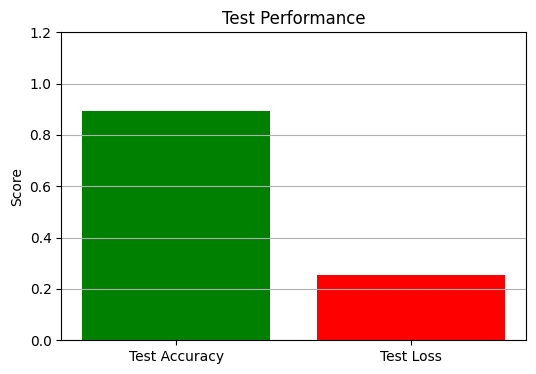

In [40]:
# Plot Test Accuracy and Test Loss
metrics = ['Test Accuracy', 'Test Loss']
values = [test_accuracy, test_loss]

plt.figure(figsize=(6,4))
plt.bar(metrics, values, color=['green', 'red'])
plt.title('Test Performance')
plt.ylim(0, 1.2)   # Set limit so accuracy and loss are both visible
plt.ylabel('Score')
plt.grid(axis='y')
plt.show()

## Option to test prediction manually with individual pictures

In [39]:
img = Image.open('images/test/driveway1.jpg').convert('RGB')
img = img.resize((128,128))
img = np.array(img)/255.0
img = np.expand_dims(img, axis=0)
prediction = dharav_model.predict(img)

print(f"prediction = {prediction[0][0]}")

if prediction[0][0] >= 0.5:
    print("Vehicle Detected")
else:
    print("No Vehicle Detected")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
prediction = 0.00230546947568655
No Vehicle Detected
